# Phase 4 — Test final FD002 (ouverture unique)

**Ce notebook ouvre `test_FD002.txt` / `RUL_FD002.txt` pour la première et unique fois.**
Jusqu'ici, toute la comparaison FD001/FD002 (H2) reposait uniquement sur la validation
(cf. mémoire, section "Limites"). Le budget d'ouverture unique n'avait jamais été dépensé
pour ce volet — contrairement à FD001, ouvert dans `07_final_test_fd001.ipynb`. Ce notebook
corrige cela : le résultat obtenu ici est rapporté tel quel dans le mémoire, sans retouche du
pipeline ou des hyperparamètres après coup, quel que soit le résultat.

**Modèles évalués** : LSTM et Transformer, tous deux dans leur configuration finale
régime-aware (14 capteurs, sélection et normalisation par régime — cf.
`11_fd002_ablation_regime.ipynb` / `14_transformer_fd002.ipynb`). Les poids sont chargés
depuis `models/lstm_fd002_seed42.pt` et `models/transformer_fd002_seed42.pt` : **aucun
réentraînement**, ce sont exactement les modèles déjà utilisés par la démo `app.py`.

**Régimes et normalisation** : le clustering k-means des régimes et les statistiques de
normalisation sont recalculés ici sur le train uniquement (même graine 42), pour retrouver
exactement le même modèle de régimes et les mêmes stats que lors de l'entraînement — puis
appliqués tels quels au test via `assign_regimes` / `normalize_by_regime`, jamais recalculés
sur le test.

**Plafonnement du RUL de test** : comme pour FD001, `RUL_FD002.txt` donne le RUL réel non
plafonné ; on le plafonne à 125 avant de calculer les scores, cohérent avec ce que les modèles
ont appris à prédire.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.metrics import asymmetric_score, rmse
from src.preprocessing import (
    add_piecewise_rul,
    assign_regimes,
    compute_norm_stats_by_regime,
    fit_regime_clusters,
    make_windows,
    normalize_by_regime,
    select_features_by_regime,
    split_by_unit,
)
from src.torch_model import RULRegressor, TransformerRULRegressor

SEED = 42
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

train_full = pd.read_csv(f"{DATA_DIR}/train_FD002.txt", sep=r"\s+", header=None)
train_full = train_full.iloc[:, : len(COL_NAMES)]
train_full.columns = COL_NAMES

# Même split que 11_fd002_ablation_regime.ipynb / 14_transformer_fd002.ipynb : reconstruit
# uniquement pour retrouver le même modèle de régimes, les mêmes capteurs sélectionnés et les
# mêmes stats de normalisation (calculées sur train_raw seul). Le val n'est pas réutilisé ici.
train_raw, _ = split_by_unit(train_full, val_fraction=0.2, seed=SEED)

regime_model = fit_regime_clusters(train_raw, SETTING_NAMES, n_regimes=6, seed=SEED)
train_regimes = assign_regimes(train_raw, SETTING_NAMES, regime_model)

selected_sensors = select_features_by_regime(train_raw, SENSOR_NAMES, train_regimes, std_threshold=1e-2)
regime_stats = compute_norm_stats_by_regime(train_raw, selected_sensors, train_regimes)

lstm = RULRegressor(n_features=len(selected_sensors), hidden_size=64)
lstm.load_state_dict(torch.load("../models/lstm_fd002_seed42.pt", map_location="cpu"))
lstm.eval()

transformer = TransformerRULRegressor(
    n_features=len(selected_sensors), window_size=WINDOW_SIZE, d_model=64, nhead=4, num_layers=1
)
transformer.load_state_dict(torch.load("../models/transformer_fd002_seed42.pt", map_location="cpu"))
transformer.eval()

len(selected_sensors)

14

In [2]:
test_raw = pd.read_csv(f"{DATA_DIR}/test_FD002.txt", sep=r"\s+", header=None)
test_raw = test_raw.iloc[:, : len(COL_NAMES)]
test_raw.columns = COL_NAMES

# Régimes affectés avec le modèle de clustering figé sur le train, et normalisation avec les
# stats du train (jamais recalculées sur le test).
test_regimes = assign_regimes(test_raw, SETTING_NAMES, regime_model)
test_norm = normalize_by_regime(test_raw, selected_sensors, test_regimes, regime_stats)

# En test, on ne prédit qu'au DERNIER cycle observé de chaque moteur (last_only=True) : c'est
# la seule position où le vrai RUL (fourni séparément) est défini.
X_test_win, _, units_test = make_windows(test_norm, selected_sensors, window_size=WINDOW_SIZE, last_only=True)

rul_true = pd.read_csv(f"{DATA_DIR}/RUL_FD002.txt", sep=r"\s+", header=None, names=["RUL"])
rul_true.index = rul_true.index + 1  # unit_number est numéroté à partir de 1, comme les lignes du fichier

y_test_true = rul_true.loc[units_test, "RUL"].clip(upper=RUL_CAP).to_numpy()

X_test_win.shape, y_test_true.shape

((259, 30, 14), (259,))

In [3]:
X_test_tensor = torch.tensor(X_test_win, dtype=torch.float32)

with torch.no_grad():
    lstm_pred = lstm(X_test_tensor).numpy()
    transformer_pred = transformer(X_test_tensor).numpy()

predictions = {"LSTM": lstm_pred, "Transformer": transformer_pred}

test_results = pd.DataFrame([
    {"modèle": name, "RMSE_test": rmse(y_test_true, y_pred), "score_asymétrique_test": asymmetric_score(y_test_true, y_pred)}
    for name, y_pred in predictions.items()
])

# Scores val (moyenne ± écart-type sur 5 graines, notebooks/16_full_seed_variance.ipynb),
# recopiés ici pour comparer généralisation val -> test, pas recalculés.
val_scores = {"LSTM": "15.21 ± 0.13", "Transformer": "15.45 ± 0.18"}
test_results["RMSE_val (5 graines)"] = test_results["modèle"].map(val_scores)

test_results[["modèle", "RMSE_val (5 graines)", "RMSE_test", "score_asymétrique_test"]]

,modèle,RMSE_val (5 graines),RMSE_test,score_asymétrique_test
0,LSTM,15.21 ± 0.13,14.278912,932.289633
1,Transformer,15.45 ± 0.18,13.758674,837.837594


**Ce que montre ce tableau** : `RMSE_val` est le score déjà obtenu sur la validation (moyenne
sur 5 graines) ; `RMSE_test` et `score_asymétrique_test` sont les scores sur le vrai test FD002,
jamais vu jusqu'ici (259 moteurs). Si `RMSE_test` reste proche de `RMSE_val`, ça confirme que la
validation donnait une estimation fiable de la généralisation sur ce volet, comme c'était déjà
le cas sur FD001.

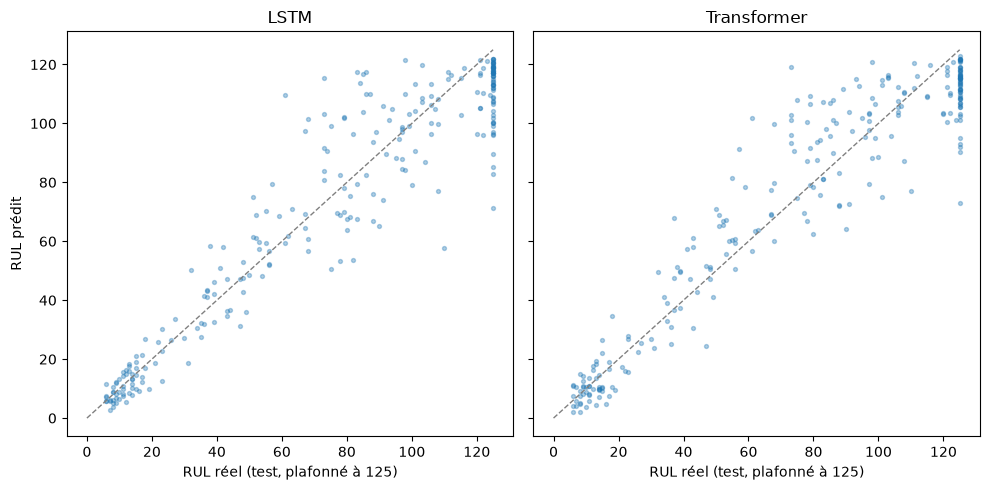

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test_true, y_pred, s=8, alpha=0.35)
    ax.plot([0, RUL_CAP], [0, RUL_CAP], color="grey", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("RUL réel (test, plafonné à 125)")

axes[0].set_ylabel("RUL prédit")
fig.tight_layout()

**Ce que montre cette figure** : chaque point est un moteur du test FD002 (un seul point par
moteur, la dernière fenêtre observée). Avec 259 moteurs, le nuage est plus dense que sur FD001
(100 moteurs). C'est la comparaison la plus directe entre LSTM et Transformer sur ce volet :
aucun des deux modèles n'a jamais vu ces données avant cette exécution.

In [5]:
import os

os.makedirs("../results", exist_ok=True)
test_results.to_csv("../results/fd002_final_test.csv", index=False)
test_results

,modèle,RMSE_test,score_asymétrique_test,RMSE_val (5 graines)
0,LSTM,14.278912,932.289633,15.21 ± 0.13
1,Transformer,13.758674,837.837594,15.45 ± 0.18
